# Student Performance Predictor

## Data Loading and Understanding

In [56]:
import pandas as pd

df = pd.read_csv("../data/StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### Dataset Overview

In [57]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (6607, 20)

Column Names:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Prev

### Statistical Summary

In [58]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Categorical Features Summary

In [59]:
df.describe(include="str")

,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6529,6607,6607,6607,6517,6540,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,3925,4598,2638,5912,3223,3884,3814


### Categorical Features and Unique Values

In [60]:
categorical_columns = df.select_dtypes(include="str").columns

for column in categorical_columns:
    print(f"{column}: {df[column].unique()}")

Parental_Involvement: <ArrowStringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Access_to_Resources: <ArrowStringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str
Extracurricular_Activities: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Motivation_Level: <ArrowStringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Internet_Access: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Family_Income: <ArrowStringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Teacher_Quality: <ArrowStringArray>
['Medium', 'High', 'Low', nan]
Length: 4, dtype: str
School_Type: <ArrowStringArray>
['Public', 'Private']
Length: 2, dtype: str
Peer_Influence: <ArrowStringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str
Learning_Disabilities: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Parental_Education_Level: <ArrowStringArray>
['High School', 'College', 'Postgraduate', nan]
Length: 4, dtype: str
Distance_from_Home: <ArrowStringArray>
['Near', 'M

## Data Cleaning

### Missing Values

In [61]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


### Duplicate Rows

In [62]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Numerical Value Ranges

In [63]:
numerical_columns = df.select_dtypes(include="number").columns

for column in numerical_columns:
    print(
        f"{column}: "
        f"Min = {df[column].min()}, "
        f"Max = {df[column].max()}"
    )

Hours_Studied: Min = 1, Max = 44
Attendance: Min = 60, Max = 100
Sleep_Hours: Min = 4, Max = 10
Previous_Scores: Min = 50, Max = 100
Tutoring_Sessions: Min = 0, Max = 8
Physical_Activity: Min = 0, Max = 6
Exam_Score: Min = 55, Max = 101


### Categorical Value Counts

In [64]:
categorical_columns = df.select_dtypes(include="str").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


Parental_Involvement:
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

Access_to_Resources:
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

Extracurricular_Activities:
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

Motivation_Level:
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

Internet_Access:
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

Family_Income:
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

Teacher_Quality:
Teacher_Quality
Medium    3925
High      1947
Low        657
NaN         78
Name: count, dtype: int64

School_Type:
School_Type
Public     4598
Private    2009
Name: count, dtype: int64

Peer_Influence:
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

Learning_Disabilities:
Learning_Disabilities
No     5912
Yes

### Check Invalid Exam Scores

In [65]:
df[df["Exam_Score"] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


### Handle Invalid Exam Scores

In [66]:
df = df[df["Exam_Score"] <= 100].copy()

df.shape

(6606, 20)

### Verify Cleaned Dataset

In [67]:
print("Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())
print("Maximum Exam Score:", df["Exam_Score"].max())

Dataset Shape: (6606, 20)
Duplicate Rows: 0
Maximum Exam Score: 100


## Exploratory Data Analysis

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

### Exam Score Distribution

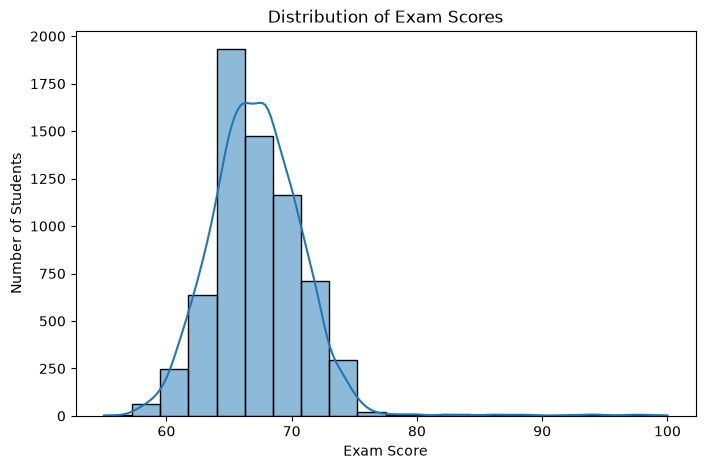

In [69]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Exam_Score", bins=20, kde=True)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

### Numerical Features vs Exam Score

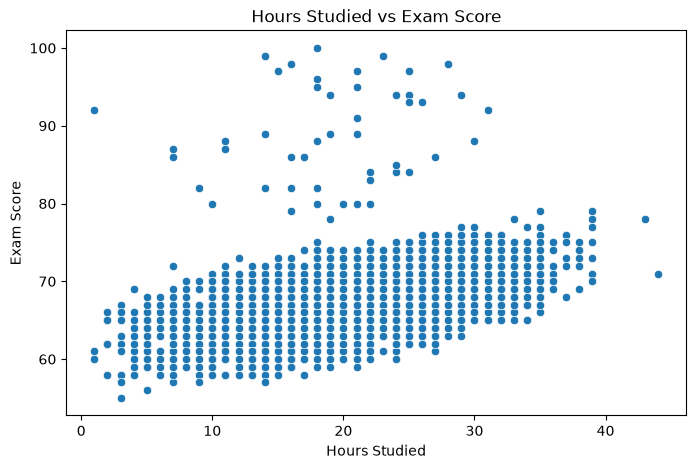

In [70]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Hours_Studied", y="Exam_Score")

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

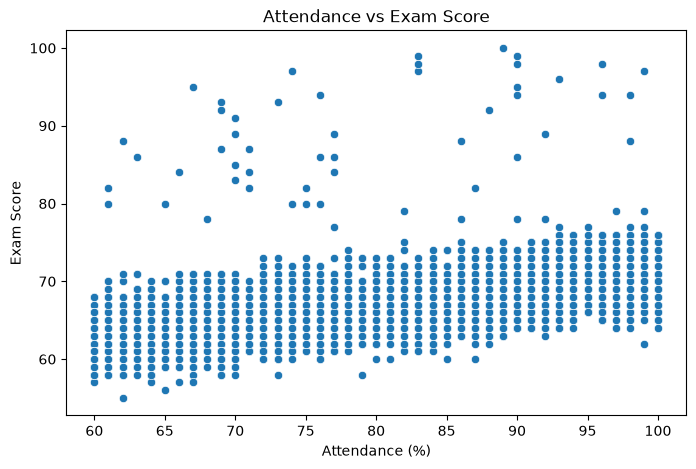

In [71]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Attendance", y="Exam_Score")

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")

plt.show()

### Other Numerical Features vs Exam Score

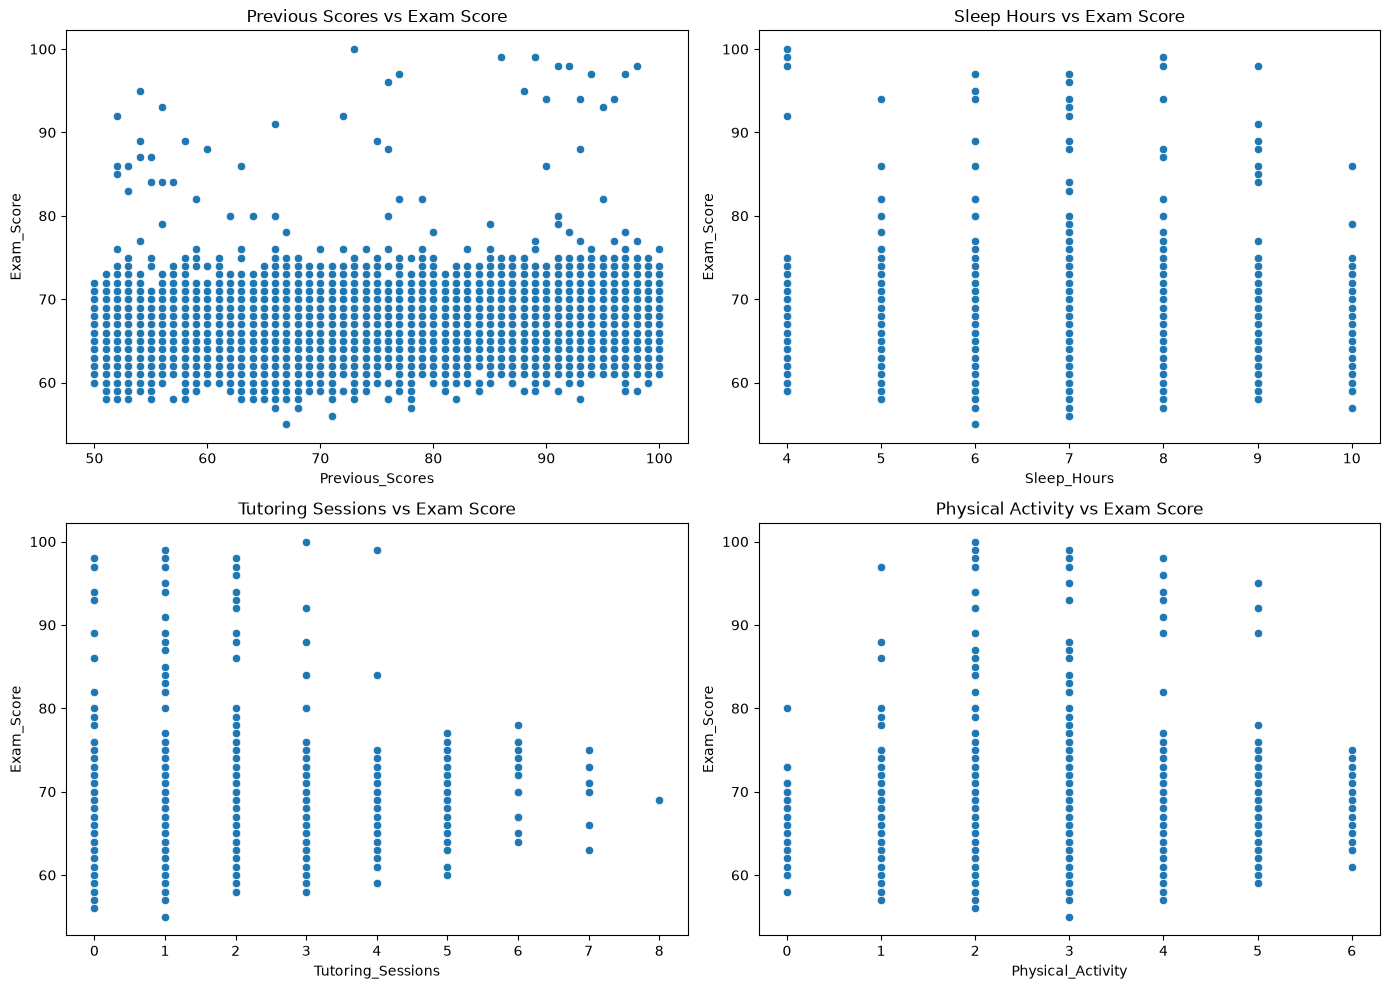

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df, x="Previous_Scores", y="Exam_Score", ax=axes[0, 0])
axes[0, 0].set_title("Previous Scores vs Exam Score")

sns.scatterplot(data=df, x="Sleep_Hours", y="Exam_Score", ax=axes[0, 1])
axes[0, 1].set_title("Sleep Hours vs Exam Score")

sns.scatterplot(data=df, x="Tutoring_Sessions", y="Exam_Score", ax=axes[1, 0])
axes[1, 0].set_title("Tutoring Sessions vs Exam Score")

sns.scatterplot(data=df, x="Physical_Activity", y="Exam_Score", ax=axes[1, 1])
axes[1, 1].set_title("Physical Activity vs Exam Score")

plt.tight_layout()
plt.show()

### Correlation Analysis

In [73]:
numerical_df = df.select_dtypes(include="number")

correlation = numerical_df.corr()

correlation["Exam_Score"].sort_values(ascending=False)

Exam_Score           1.000000
Attendance           0.582458
Hours_Studied        0.446514
Previous_Scores      0.174461
Tutoring_Sessions    0.153754
Physical_Activity    0.027943
Sleep_Hours         -0.016194
Name: Exam_Score, dtype: float64

### Correlation Heatmap

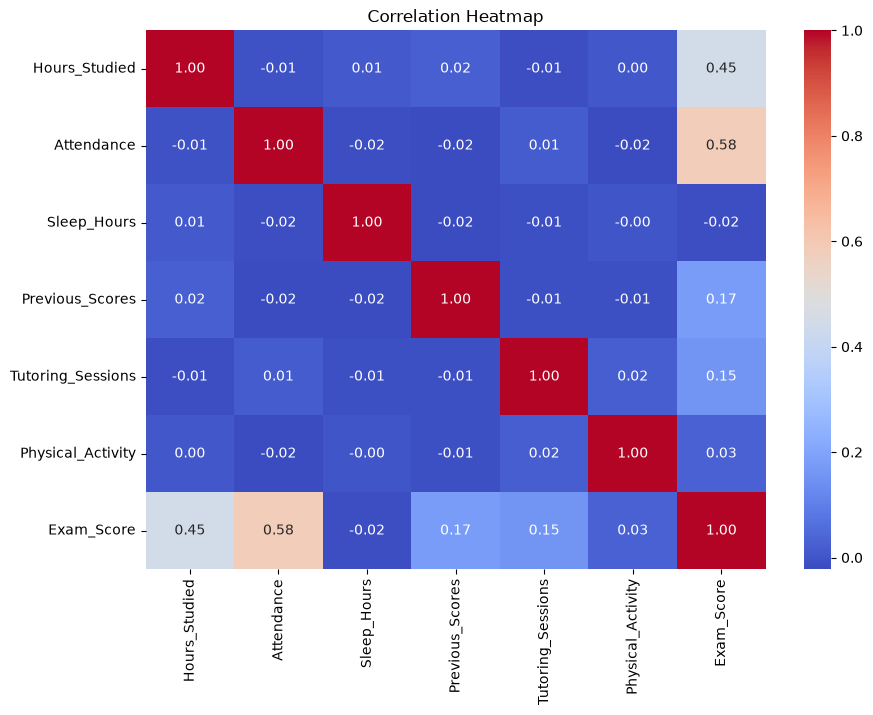

In [74]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Ordinal Categorical Features vs Exam Score

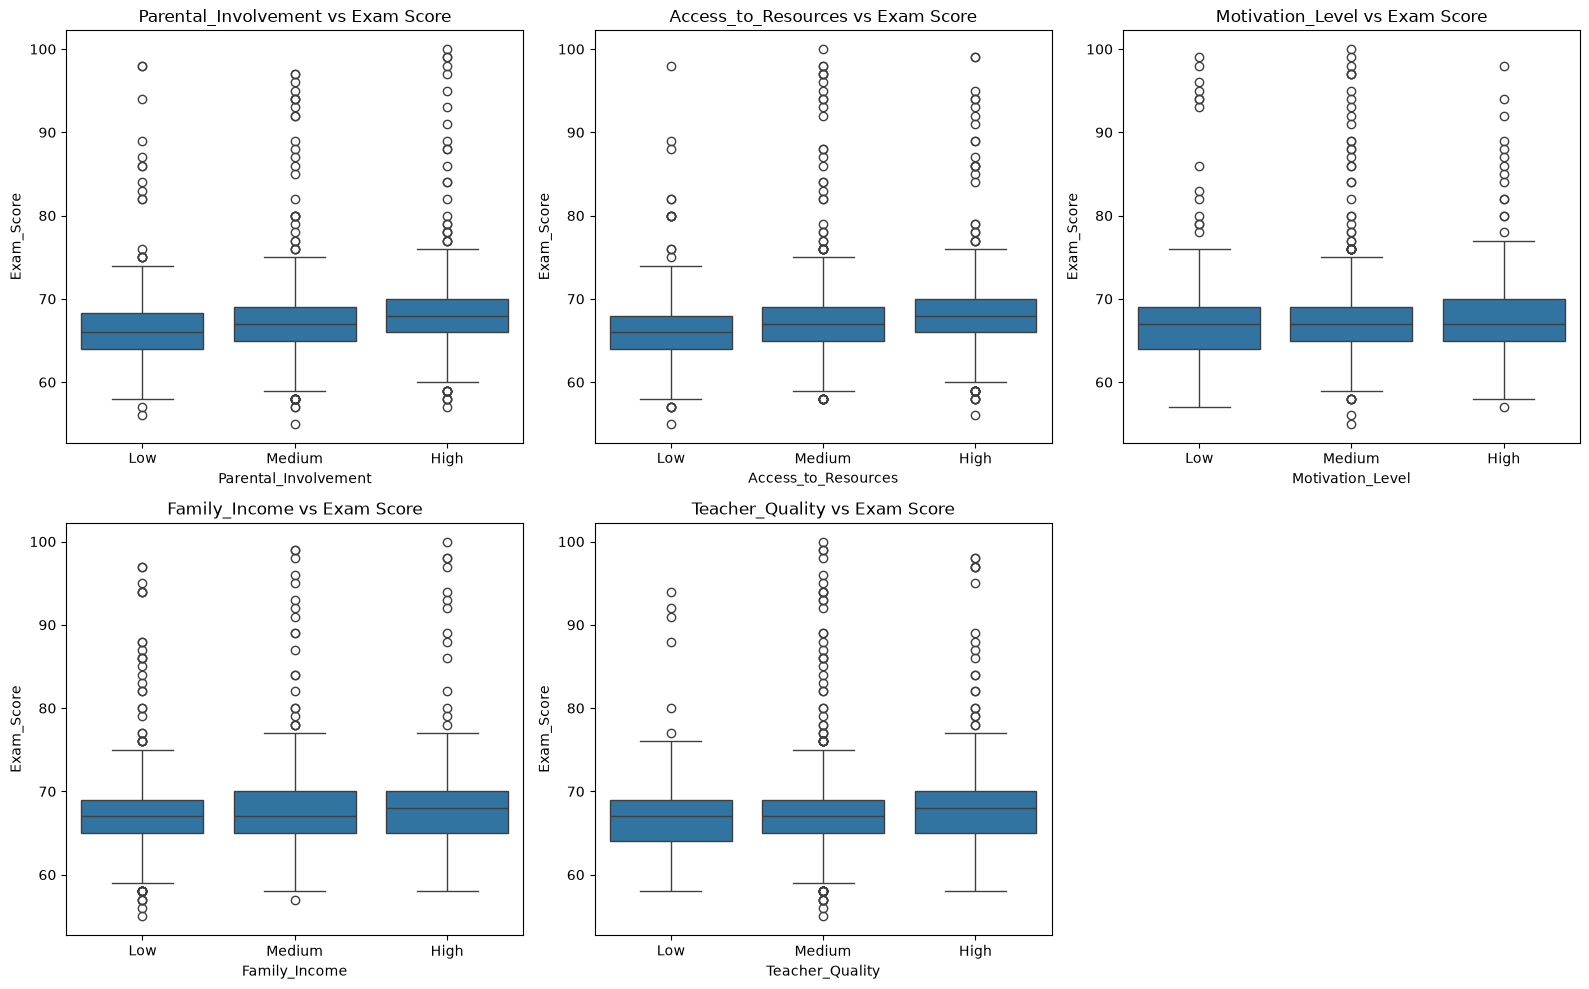

In [75]:
ordinal_features = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Family_Income",
    "Teacher_Quality"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, column in enumerate(ordinal_features):
    sns.boxplot(
        data=df,
        x=column,
        y="Exam_Score",
        ax=axes[i],
        order=["Low", "Medium", "High"]
    )
    axes[i].set_title(f"{column} vs Exam Score")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

### Binary Categorical Features vs Exam Score

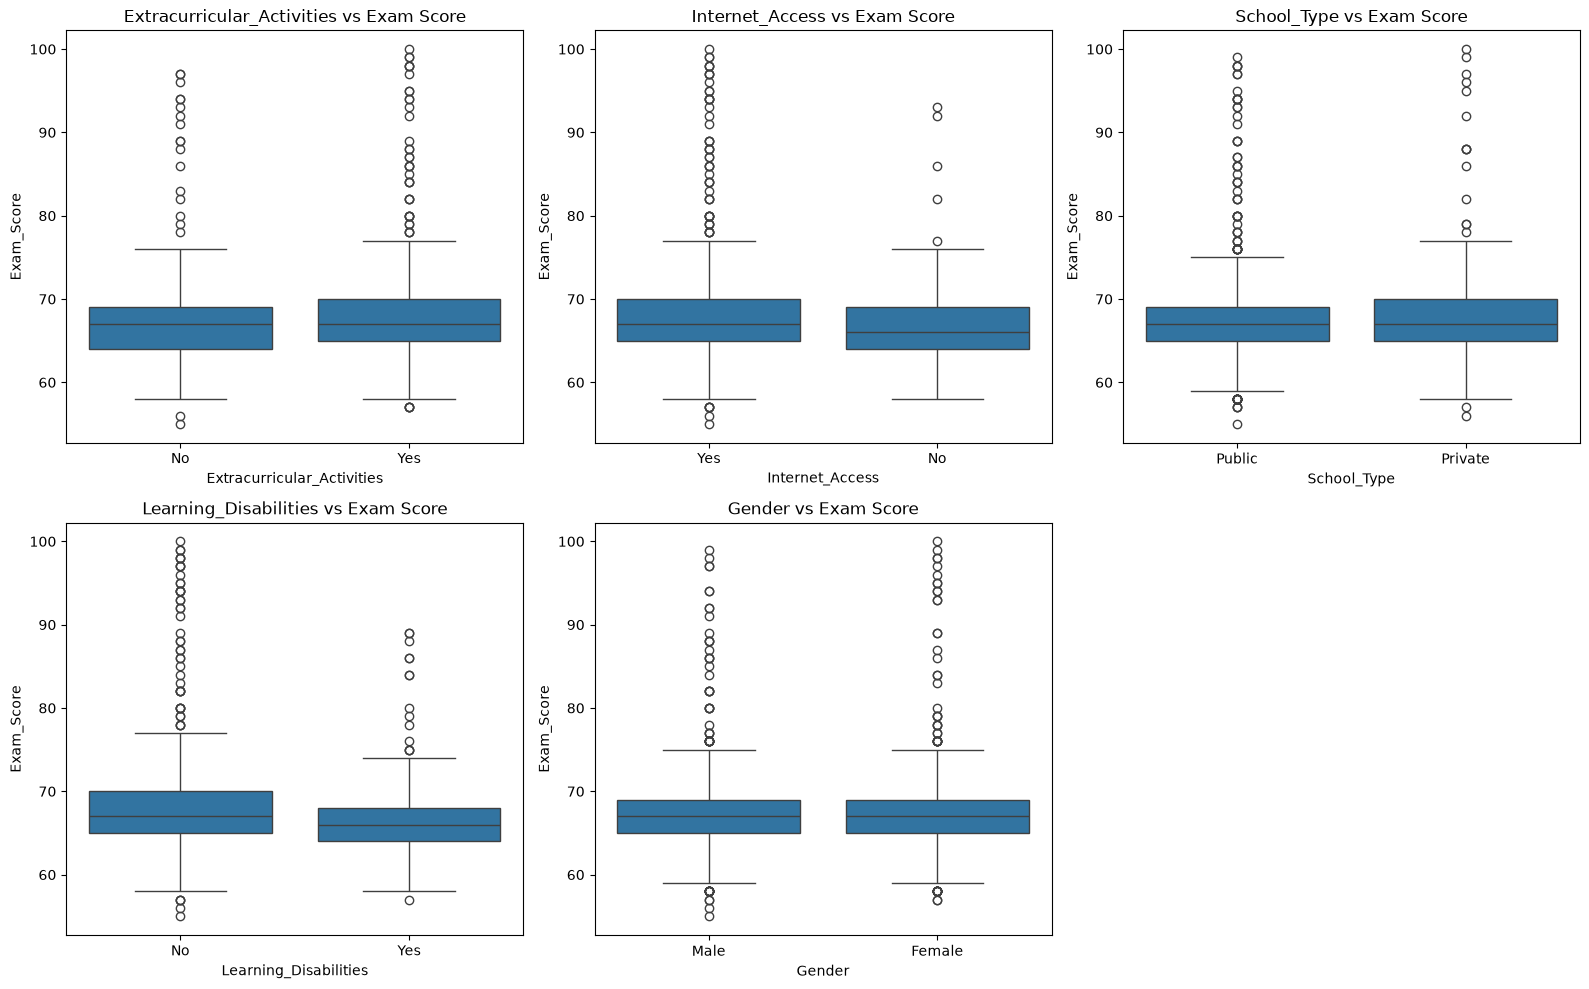

In [76]:
binary_features = [
    "Extracurricular_Activities",
    "Internet_Access",
    "School_Type",
    "Learning_Disabilities",
    "Gender"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, column in enumerate(binary_features):
    sns.boxplot(
        data=df,
        x=column,
        y="Exam_Score",
        ax=axes[i]
    )
    axes[i].set_title(f"{column} vs Exam Score")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

### Other Categorical Features vs Exam Score

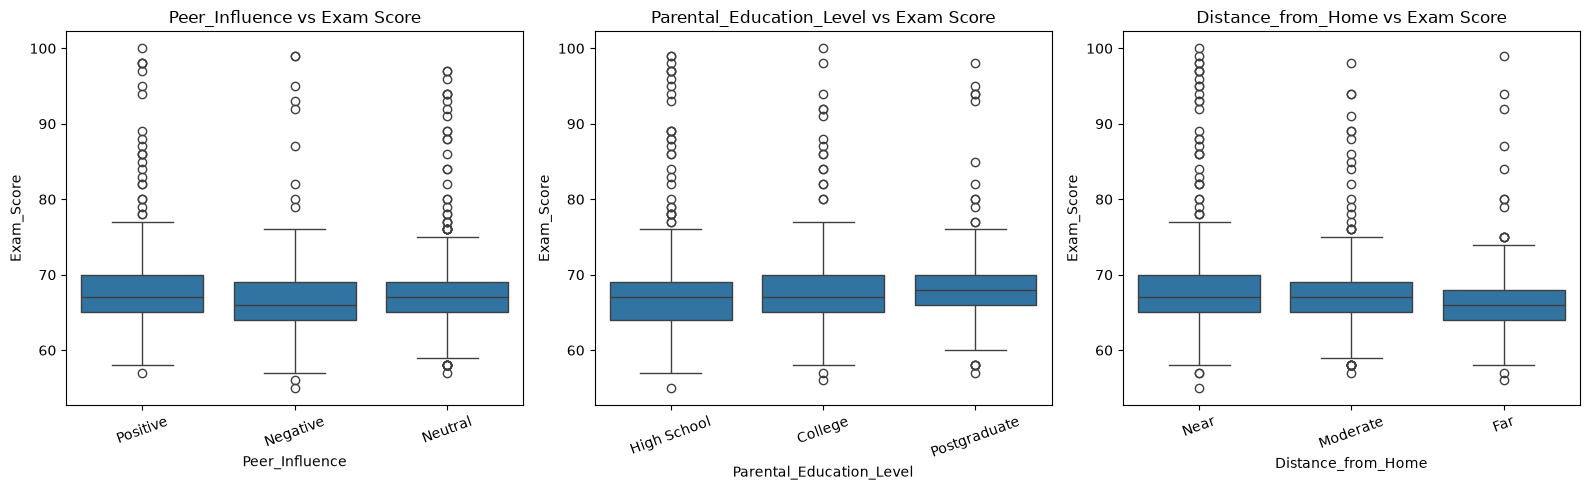

In [77]:
other_features = [
    "Peer_Influence",
    "Parental_Education_Level",
    "Distance_from_Home"
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, column in enumerate(other_features):
    sns.boxplot(
        data=df,
        x=column,
        y="Exam_Score",
        ax=axes[i]
    )
    axes[i].set_title(f"{column} vs Exam Score")
    axes[i].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Define Features and Target

In [78]:
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (6606, 19)
Target Shape: (6606,)


### Verify Features and Target

In [79]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Target:
Exam_Score


## Feature Selection

In [80]:
selected_features = [
    "Hours_Studied",
    "Attendance",
    "Parental_Involvement",
    "Access_to_Resources",
    "Extracurricular_Activities",
    "Sleep_Hours",
    "Previous_Scores",
    "Motivation_Level",
    "Internet_Access",
    "Tutoring_Sessions",
    "Family_Income",
    "Teacher_Quality",
    "School_Type",
    "Peer_Influence",
    "Physical_Activity",
    "Learning_Disabilities",
    "Parental_Education_Level",
    "Distance_from_Home",
    "Gender"
]

X = df[selected_features]
y = df["Exam_Score"]

print("Number of Selected Features:", len(selected_features))
print("X Shape:", X.shape)
print("y Shape:", y.shape)

Number of Selected Features: 19
X Shape: (6606, 19)
y Shape: (6606,)


### Selected Feature Types

In [81]:
numerical_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(include="str").columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nNumerical Features:", len(numerical_features))
print("Categorical Features:", len(categorical_features))

Numerical Features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical Features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Numerical Features: 6
Categorical Features: 13


## Train-Test Split

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (5284, 19)
X_test Shape: (1322, 19)
y_train Shape: (5284,)
y_test Shape: (1322,)


### Training and Testing Data

In [83]:
print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

print("\nTraining Percentage:", round(len(X_train) / len(X) * 100, 2), "%")
print("Testing Percentage:", round(len(X_test) / len(X) * 100, 2), "%")

Training Data: 5284
Testing Data: 1322

Training Percentage: 79.99 %
Testing Percentage: 20.01 %


## Data Preprocessing

In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### Transform Training and Testing Data

In [85]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train Before Preprocessing:", X_train.shape)
print("X_train After Preprocessing:", X_train_processed.shape)

print("\nX_test Before Preprocessing:", X_test.shape)
print("X_test After Preprocessing:", X_test_processed.shape)

X_train Before Preprocessing: (5284, 19)
X_train After Preprocessing: (5284, 40)

X_test Before Preprocessing: (1322, 19)
X_test After Preprocessing: (1322, 40)


### Processed Feature Names

In [86]:
processed_feature_names = preprocessor.get_feature_names_out()

print("Total Processed Features:", len(processed_feature_names))

for feature in processed_feature_names:
    print(feature)

Total Processed Features: 40
num__Hours_Studied
num__Attendance
num__Sleep_Hours
num__Previous_Scores
num__Tutoring_Sessions
num__Physical_Activity
cat__Parental_Involvement_High
cat__Parental_Involvement_Low
cat__Parental_Involvement_Medium
cat__Access_to_Resources_High
cat__Access_to_Resources_Low
cat__Access_to_Resources_Medium
cat__Extracurricular_Activities_No
cat__Extracurricular_Activities_Yes
cat__Motivation_Level_High
cat__Motivation_Level_Low
cat__Motivation_Level_Medium
cat__Internet_Access_No
cat__Internet_Access_Yes
cat__Family_Income_High
cat__Family_Income_Low
cat__Family_Income_Medium
cat__Teacher_Quality_High
cat__Teacher_Quality_Low
cat__Teacher_Quality_Medium
cat__School_Type_Private
cat__School_Type_Public
cat__Peer_Influence_Negative
cat__Peer_Influence_Neutral
cat__Peer_Influence_Positive
cat__Learning_Disabilities_No
cat__Learning_Disabilities_Yes
cat__Parental_Education_Level_College
cat__Parental_Education_Level_High School
cat__Parental_Education_Level_Postgra

### Processed Training Data

In [87]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train.index
)

X_train_processed_df.head()

,num__Hours_Studied,num__Attendance,num__Sleep_Hours,num__Previous_Scores,num__Tutoring_Sessions,num__Physical_Activity,cat__Parental_Involvement_High,cat__Parental_Involvement_Low,cat__Parental_Involvement_Medium,cat__Access_to_Resources_High,...,cat__Learning_Disabilities_No,cat__Learning_Disabilities_Yes,cat__Parental_Education_Level_College,cat__Parental_Education_Level_High School,cat__Parental_Education_Level_Postgraduate,cat__Distance_from_Home_Far,cat__Distance_from_Home_Moderate,cat__Distance_from_Home_Near,cat__Gender_Female,cat__Gender_Male
5937,11.0,75.0,9.0,77.0,1.0,2.0,1.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4417,8.0,73.0,8.0,78.0,0.0,3.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2949,10.0,76.0,4.0,68.0,1.0,6.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3086,20.0,84.0,7.0,74.0,1.0,3.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
5820,20.0,62.0,4.0,98.0,1.0,4.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


## Baseline Model Training

In [88]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Linear Regression Predictions

In [89]:
linear_predictions = linear_model.predict(X_test_processed)

print("Number of Predictions:", len(linear_predictions))
print("\nFirst 10 Predicted Exam Scores:")
print(linear_predictions[:10])

Number of Predictions: 1322

First 10 Predicted Exam Scores:
[66.01458738 65.44513872 67.57892942 67.65086257 68.00528256 63.2533034
 74.01360008 65.07475661 68.96931007 75.70952187]


### Predicted vs Actual Scores

In [90]:
comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": linear_predictions
})

comparison["Predicted Score"] = comparison["Predicted Score"].round(2)

comparison.head(10)

,Actual Score,Predicted Score
0,66,66.01
1,66,65.45
2,67,67.58
3,67,67.65
4,68,68.01
5,63,63.25
6,74,74.01
7,65,65.07
8,69,68.97
9,76,75.71


## Model Evaluation

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, linear_predictions)
mse = mean_squared_error(y_test, linear_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Linear Regression Results
MAE: 0.42
MSE: 2.31
RMSE: 1.52
R² Score: 0.825


### Actual vs Predicted Scores

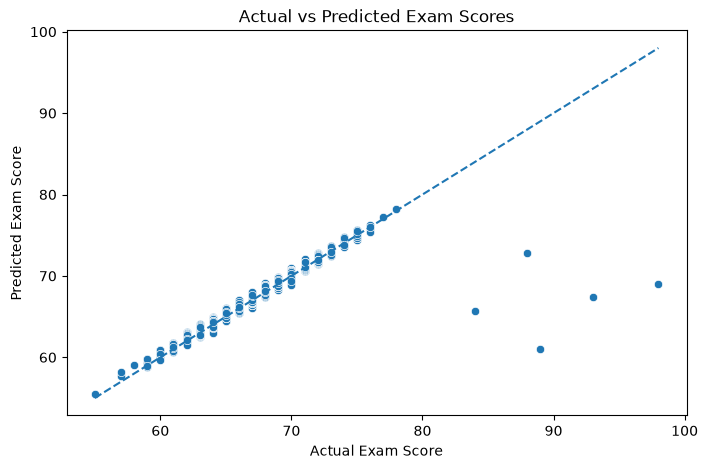

In [92]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test,
    y=linear_predictions
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.show()

### Largest Prediction Errors

In [93]:
error_analysis = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": linear_predictions
})

error_analysis["Absolute Error"] = abs(
    error_analysis["Actual Score"] - error_analysis["Predicted Score"]
)

error_analysis["Predicted Score"] = error_analysis["Predicted Score"].round(2)
error_analysis["Absolute Error"] = error_analysis["Absolute Error"].round(2)

error_analysis.sort_values(
    by="Absolute Error",
    ascending=False
).head(10)

,Actual Score,Predicted Score,Absolute Error
662,98,69.04,28.96
136,89,61.05,27.95
892,93,67.37,25.63
97,84,65.66,18.34
1072,88,72.81,15.19
1128,57,58.14,1.14
712,68,69.14,1.14
932,71,72.08,1.08
363,63,64.07,1.07
23,65,66.06,1.06


## Model Comparison

In [94]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

decision_tree_model = DecisionTreeRegressor(random_state=42)

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)

### Train Comparison Models

In [95]:
decision_tree_model.fit(X_train_processed, y_train)
random_forest_model.fit(X_train_processed, y_train)
gradient_boosting_model.fit(X_train_processed, y_train)

print("Decision Tree trained successfully.")
print("Random Forest trained successfully.")
print("Gradient Boosting trained successfully.")

Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


### Comparison Model Predictions

In [96]:
decision_tree_predictions = decision_tree_model.predict(X_test_processed)
random_forest_predictions = random_forest_model.predict(X_test_processed)
gradient_boosting_predictions = gradient_boosting_model.predict(X_test_processed)

print("Decision Tree Predictions:", len(decision_tree_predictions))
print("Random Forest Predictions:", len(random_forest_predictions))
print("Gradient Boosting Predictions:", len(gradient_boosting_predictions))

Decision Tree Predictions: 1322
Random Forest Predictions: 1322
Gradient Boosting Predictions: 1322


### Model Performance Comparison

In [97]:
def evaluate_model(name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    mse = mean_squared_error(y_true, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, predictions)

    return {
        "Model": name,
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "R²": round(r2, 4)
    }


model_results = [
    evaluate_model("Linear Regression", y_test, linear_predictions),
    evaluate_model("Decision Tree", y_test, decision_tree_predictions),
    evaluate_model("Random Forest", y_test, random_forest_predictions),
    evaluate_model("Gradient Boosting", y_test, gradient_boosting_predictions)
]

results_df = pd.DataFrame(model_results)

results_df

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.42,2.31,1.52,0.8250
1,Decision Tree,1.87,14.32,3.78,-0.0826
2,Random Forest,1.07,3.87,1.97,0.7076
3,Gradient Boosting,0.75,2.89,1.70,0.7813


### Largest Errors Across Models

In [98]:
model_error_comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Linear Regression": linear_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions,
    "Gradient Boosting": gradient_boosting_predictions
})

model_error_comparison["Linear Error"] = abs(
    model_error_comparison["Actual Score"] - model_error_comparison["Linear Regression"]
)

largest_linear_errors = model_error_comparison.sort_values(
    by="Linear Error",
    ascending=False
).head(10)

largest_linear_errors = largest_linear_errors.round(2)

largest_linear_errors

,Actual Score,Linear Regression,Decision Tree,Random Forest,Gradient Boosting,Linear Error
662,98,69.04,69.0,67.62,68.09,28.96
136,89,61.05,64.0,62.77,62.44,27.95
892,93,67.37,66.0,66.79,66.48,25.63
97,84,65.66,62.0,65.76,65.53,18.34
1072,88,72.81,77.0,73.78,73.64,15.19
712,68,69.14,70.0,70.19,68.67,1.14
1128,57,58.14,60.0,62.00,62.84,1.14
932,71,72.08,70.0,71.76,71.95,1.08
363,63,64.07,61.0,62.97,63.73,1.07
23,65,66.06,66.0,65.89,67.89,1.06


## Final Model Selection

### Cross-Validation

In [99]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

cv_models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

cv_pipelines = {}

for name, model in cv_models.items():
    cv_pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", model)
        ]
    )

### 5-Fold Cross-Validation Results

In [100]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results = []

for name, pipeline in cv_pipelines.items():

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R²": scores["test_R2"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df[
    ["CV MAE", "CV RMSE", "CV R²"]
] = cv_results_df[
    ["CV MAE", "CV RMSE", "CV R²"]
].round(4)

cv_results_df

,Model,CV MAE,CV RMSE,CV R²
0,Linear Regression,0.5116,2.0840,0.7166
1,Decision Tree,1.8626,3.6220,0.1319
2,Random Forest,1.1895,2.4296,0.6163
3,Gradient Boosting,0.8607,2.2417,0.6730


### Hyperparameter Tuning

#### Decision Tree Tuning

In [101]:
from sklearn.model_selection import GridSearchCV

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

decision_tree_params = {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [102]:
decision_tree_grid = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=decision_tree_params,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

decision_tree_grid.fit(X_train, y_train)

print("Best Parameters:")
print(decision_tree_grid.best_params_)

print(
    "\nBest CV MAE:",
    round(-decision_tree_grid.best_score_, 4)
)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}

Best CV MAE: 1.663


#### Random Forest Tuning

In [103]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

random_forest_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [104]:
random_forest_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_params,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

random_forest_grid.fit(X_train, y_train)

print("Best Parameters:")
print(random_forest_grid.best_params_)

print(
    "\nBest CV MAE:",
    round(-random_forest_grid.best_score_, 4)
)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV MAE: 1.1474


#### Gradient Boosting Tuning

In [105]:
gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)

gradient_boosting_params = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [1, 2, 4]
}

In [110]:
gradient_boosting_grid = GridSearchCV(
    estimator=gradient_boosting_pipeline,
    param_grid=gradient_boosting_params,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

gradient_boosting_grid.fit(X_train, y_train)

print("Best Parameters:")
print(gradient_boosting_grid.best_params_)

print(
    "\nBest CV MAE:",
    round(-gradient_boosting_grid.best_score_, 4)
)

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}

Best CV MAE: 0.7478


### Final Candidate Models

In [ ]:
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", LinearRegression())
    ]
)

linear_pipeline.fit(X_train, y_train)

tuned_decision_tree = decision_tree_grid.best_estimator_
tuned_random_forest = random_forest_grid.best_estimator_
tuned_gradient_boosting = gradient_boosting_grid.best_estimator_

### Final Test Predictions

In [107]:
final_linear_predictions = linear_pipeline.predict(X_test)
final_decision_tree_predictions = tuned_decision_tree.predict(X_test)
final_random_forest_predictions = tuned_random_forest.predict(X_test)
final_gradient_boosting_predictions = tuned_gradient_boosting.predict(X_test)

### Final Test Predictions

In [108]:
final_results = [
    evaluate_model(
        "Linear Regression",
        y_test,
        final_linear_predictions
    ),
    evaluate_model(
        "Tuned Decision Tree",
        y_test,
        final_decision_tree_predictions
    ),
    evaluate_model(
        "Tuned Random Forest",
        y_test,
        final_random_forest_predictions
    ),
    evaluate_model(
        "Tuned Gradient Boosting",
        y_test,
        final_gradient_boosting_predictions
    )
]

final_results_df = pd.DataFrame(final_results)

final_results_df

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.42,2.31,1.52,0.8250
1,Tuned Decision Tree,1.52,6.28,2.51,0.5248
2,Tuned Random Forest,1.03,3.66,1.91,0.7233
3,Tuned Gradient Boosting,0.63,2.61,1.62,0.8025


### Final Model Selection

Linear Regression was selected as the final model because it achieved the lowest MAE and RMSE and the highest R² score among all evaluated models. Its performance was also validated using 5-fold cross-validation.

In [109]:
final_model = linear_pipeline

print("Final Model: Linear Regression")
print("MAE: 0.42")
print("RMSE: 1.52")
print("R² Score: 0.8250")

Final Model: Linear Regression
MAE: 0.42
RMSE: 1.52
R² Score: 0.8250


## Save the ML Pipeline

In [112]:
import joblib

model_path = "../model/student_model.pkl"

joblib.dump(final_model, model_path)

print("Model saved successfully.")
print("Saved to:", model_path)

Model saved successfully.
Saved to: ../model/student_model.pkl


### Load Saved Model

In [113]:
loaded_model = joblib.load(model_path)

print("Model loaded successfully.")
print(loaded_model)

Model loaded successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Hours_Studied',
                                                   'Attendance', 'Sleep_Hours',
                                                   'Previous_Scores',
                                                   'Tutoring_Sessions',
                                                   'Physical_Activity']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
               

### Test Saved Model

In [114]:
loaded_predictions = loaded_model.predict(X_test)

print("Number of Predictions:", len(loaded_predictions))
print("\nFirst 10 Predictions:")
print(loaded_predictions[:10])

Number of Predictions: 1322

First 10 Predictions:
[66.01458738 65.44513872 67.57892942 67.65086257 68.00528256 63.2533034
 74.01360008 65.07475661 68.96931007 75.70952187]


In [115]:
import numpy as np

predictions_match = np.allclose(
    final_linear_predictions,
    loaded_predictions
)

print("Saved model predictions match:", predictions_match)

Saved model predictions match: True


### Test New Student Prediction

In [116]:
new_student = pd.DataFrame({
    "Hours_Studied": [20],
    "Attendance": [85],
    "Parental_Involvement": ["High"],
    "Access_to_Resources": ["High"],
    "Extracurricular_Activities": ["Yes"],
    "Sleep_Hours": [7],
    "Previous_Scores": [80],
    "Motivation_Level": ["High"],
    "Internet_Access": ["Yes"],
    "Tutoring_Sessions": [2],
    "Family_Income": ["Medium"],
    "Teacher_Quality": ["High"],
    "School_Type": ["Public"],
    "Peer_Influence": ["Positive"],
    "Physical_Activity": [3],
    "Learning_Disabilities": ["No"],
    "Parental_Education_Level": ["College"],
    "Distance_from_Home": ["Near"],
    "Gender": ["Female"]
})

predicted_score = loaded_model.predict(new_student)[0]

print("Predicted Exam Score:", round(predicted_score, 2))

Predicted Exam Score: 72.97
